In [1]:
import numpy as np
from qubicpack.qubicfp import qubicfp
import sys,os
import glob

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

In [2]:
day = '2023-05-29'
data_dir = '/home/qubic/Calib-TD/'+day+'/'
words = ['DomeOpened']
keywords = ['*{}*'.format(word) for word in words]
for keyword in keywords:
    dirs = np.sort(glob.glob(data_dir+keyword))
    print(dirs)

['/home/qubic/Calib-TD/2023-05-29/2023-05-29_01.45.22__SkyScan-2.5V-DomeOpened-Night'
 '/home/qubic/Calib-TD/2023-05-29/2023-05-29_11.20.47__SkyScan-2.5V-DomeOpened-Day'
 '/home/qubic/Calib-TD/2023-05-29/2023-05-29_14.56.02__SkyScan-3V-DomeOpened-Day'
 '/home/qubic/Calib-TD/2023-05-29/2023-05-29_15.19.18__SkyScan-2V-DomeOpened-Day'
 '/home/qubic/Calib-TD/2023-05-29/2023-05-29_15.21.00__SkyScan-2V-DomeOpened-Day'
 '/home/qubic/Calib-TD/2023-05-29/2023-05-29_19.37.22__SkyDip-2V-DomeOpened-Day']


In [ ]:
data_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/data/Flux_jumps/"
soft_path = "/home/belen/Doctorado/qubic-dev/qubic/qubic/scripts/Calibration/Flux_jumps/"
sys.path.append(os.path.abspath(soft_path))

In [3]:
import jumps_review as jr
import utilities as utils

## 01.45.22 skyscan 2.5V

In [6]:
dataset0 = dirs[0]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-29 01:45:22.998000
ASIC1 Observation end date: 2023-05-29 05:10:35.738000
ASIC2     Observation date: 2023-05-29 01:45:22.999000
ASIC2 Observation end date: 2023-05-29 05:10:35.738000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_01.45.22__SkyScan-2.5V-DomeOpened-Night/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_01.45.22__SkyScan-2.5V-DomeOpened-Night/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230529T014522UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230529T014522UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Please

True

In [7]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=1933312 which is  2^15*59
number of timesamples along every TES in this dataset: (1933312,)


In [8]:
tt[-1]/60/60

3.4202204444673328

In [9]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [10]:
sat = jr.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   4   5   7  15  19  20  21  22  24  25  26  27  28  30  31  32  33
  38  45  49  50  53  57  58  59  60  61  62  63  65  66  68  69  70  71
  72  75  77  80  81  83  84  85  86  87  88  89  90  92  93  94  95  97
  98 100 102 105 110 111 112 115 116 121 128 129 130 132 133 134 135 136
 139 141 142 144 145 146 147 148 149 150 151 152 155 157 158 159 160 161
 162 166 167 168 169 171 172 173 174 175 177 178 179 180 181 182 184 185
 186 187 188 192 193 194 196 197 198 199 200 201 202 204 205 206 207 208
 209 211 212 213 214 215 216 217 219 220 222 223 224 232 234 235 238 239
 241 243 245 246 247 248 251 254 255]


In [11]:
np.where(iv_mask==False)[0]

array([ 16,  17,  23,  42,  44,  46,  47,  64,  73,  78,  96,  99, 101,
       113, 117, 118, 119, 122, 124, 125, 126, 127, 143, 153, 154, 156,
       165, 176, 189, 190, 191, 218, 221, 225, 226, 227, 228, 229, 230,
       249, 250, 252, 253])

In [38]:
thr = [3e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 700  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [39]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [42]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [43]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

In [ ]:
utils.plot_no_jumps(tt, todarray, results)

/home/belen/Doctorado/qubic-dev/jumps/pipeline/soft/utilities.py:134: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


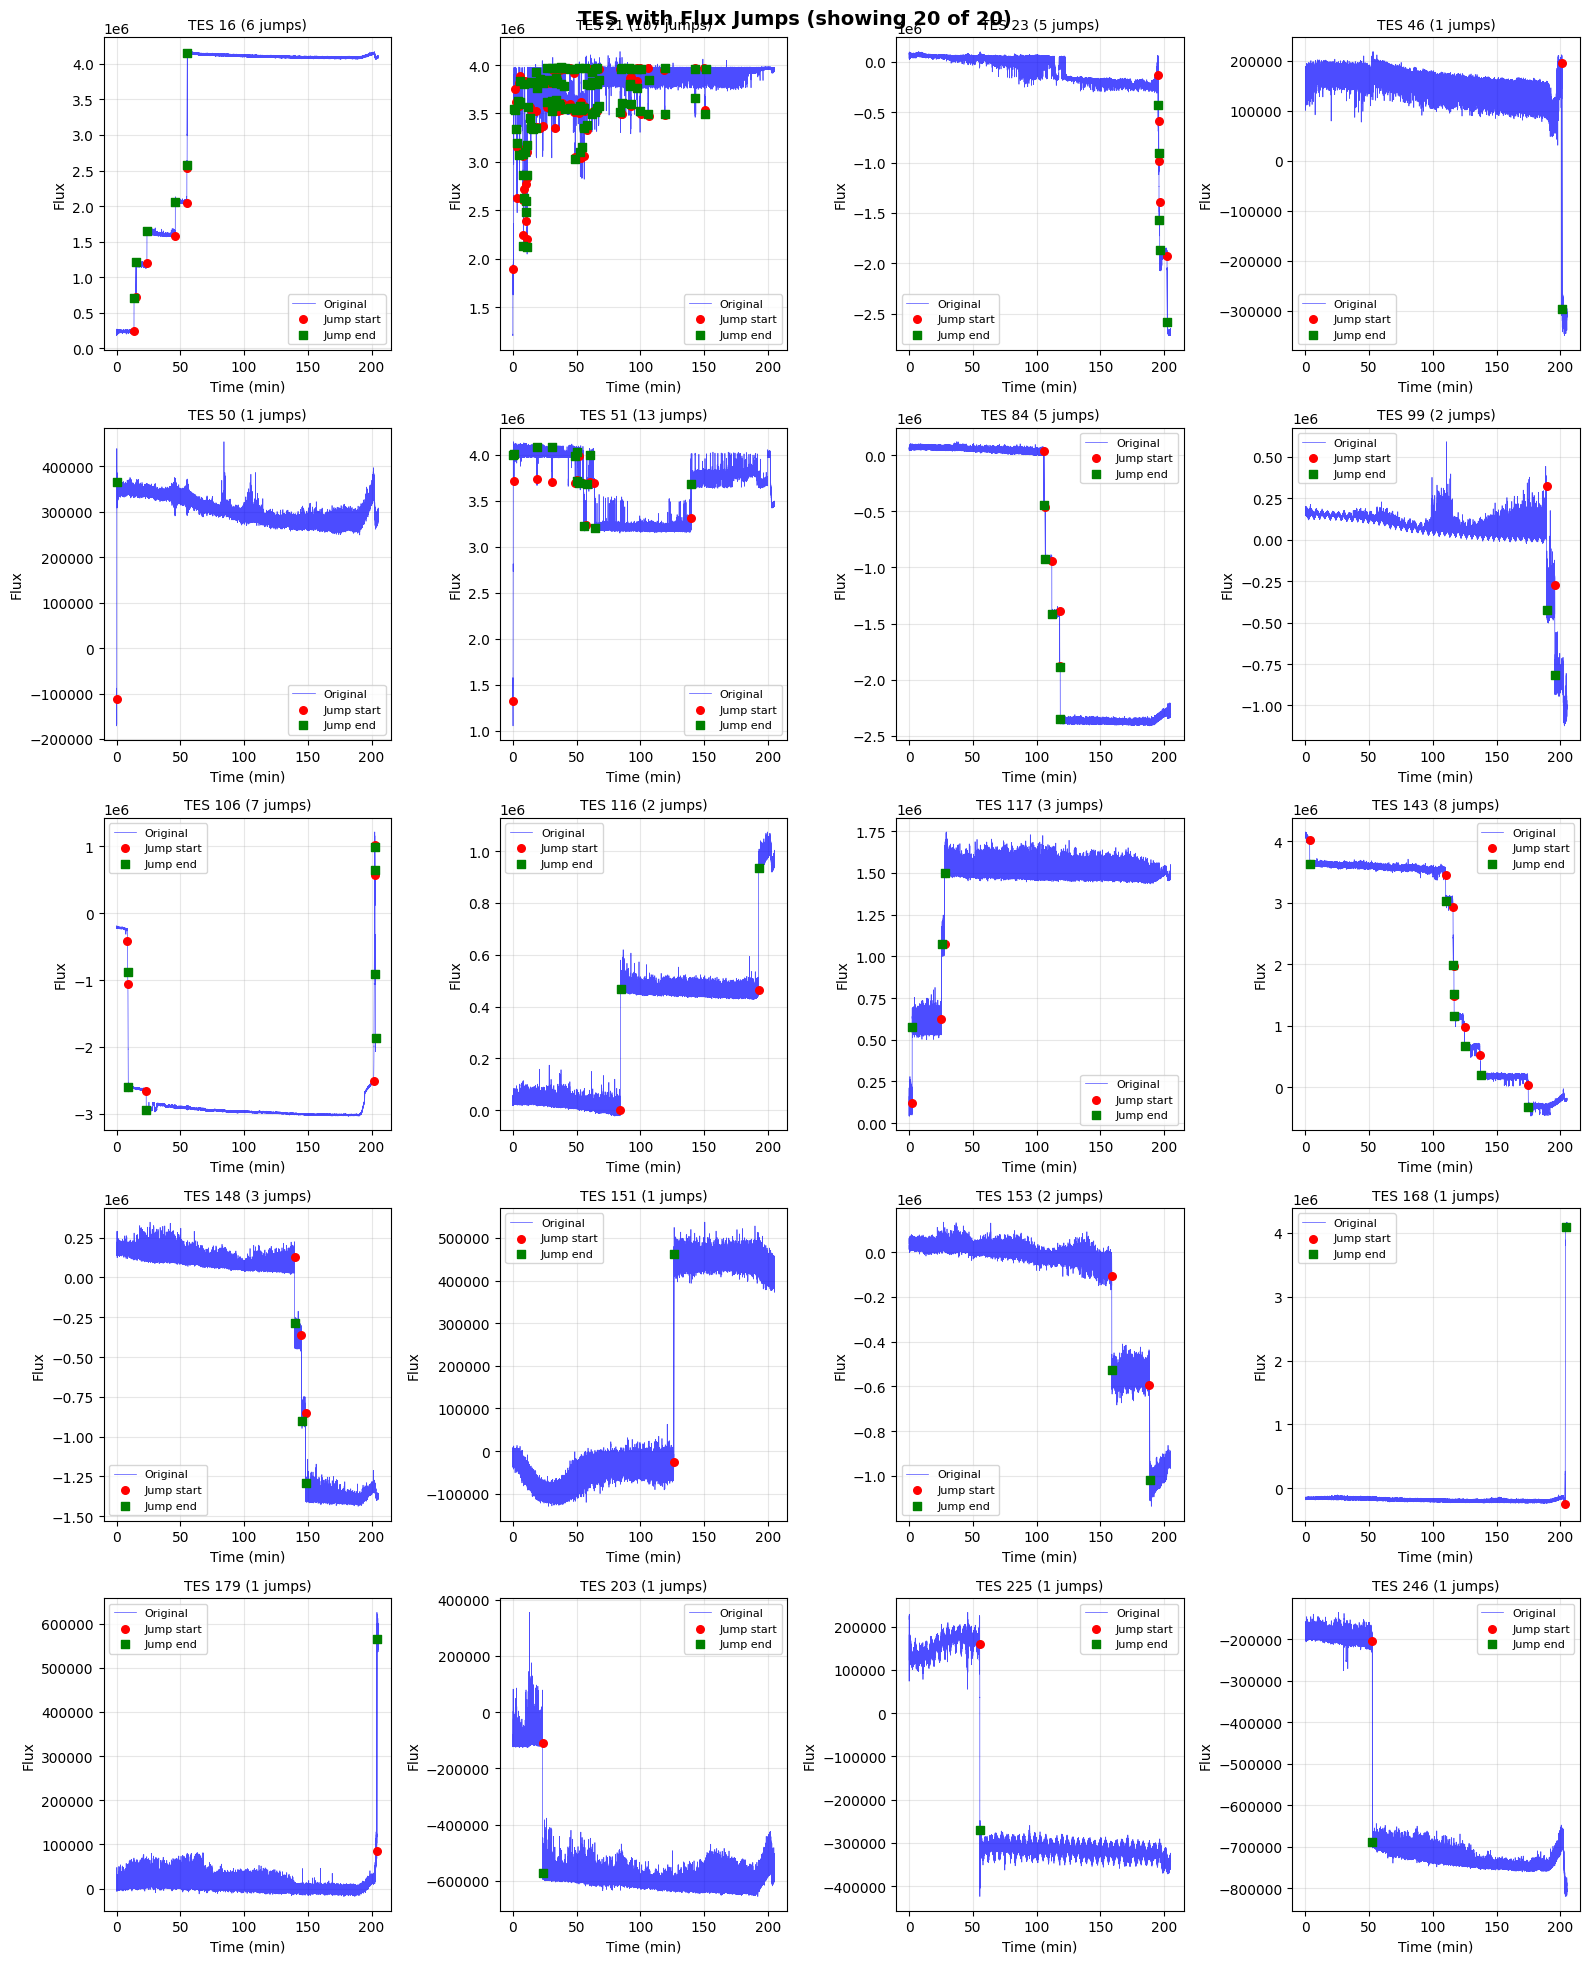

0

In [44]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [46]:
%matplotlib notebook

In [49]:
jump_data[50]

{'nc': 13,
 'xc': array([   1433,   10385,  179094,  291045,  460747,  471787,  476274,
         488078,  521803,  543480,  566770,  602444, 1316635]),
 'xcf': array([   3765,   11666,  180042,  292090,  461669,  472611,  477016,
         489068,  522686,  544594,  567550,  603530, 1317646]),
 'thr_used': 300000.0}

<IPython.core.display.Javascript object>


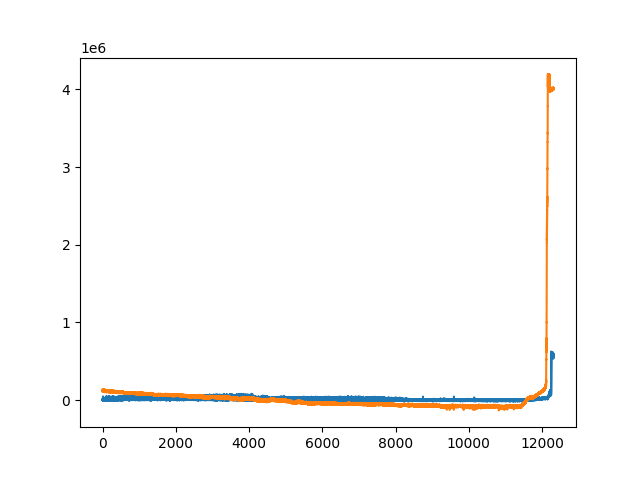

In [61]:
plt.plot(tt, todarray[178])
plt.plot(tt, todarray[40])

In [4]:
dirs[1]

'/home/qubic/Calib-TD/2023-05-29/2023-05-29_11.20.47__SkyScan-2.5V-DomeOpened-Day'

## 11.20.47 skyscan 2.5V

In [5]:
dataset0 = dirs[1]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-29 11:20:48.001000
ASIC1 Observation end date: 2023-05-29 14:52:33.720000
ASIC2     Observation date: 2023-05-29 11:20:48.000000
ASIC2 Observation end date: 2023-05-29 14:52:33.720000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_11.20.47__SkyScan-2.5V-DomeOpened-Day/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_11.20.47__SkyScan-2.5V-DomeOpened-Day/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230529T112048UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230529T112048UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Please ent

True

In [6]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=1998848 which is  2^15*61
number of timesamples along every TES in this dataset: (1998848,)


In [8]:
tt[-1]/60/60

3.529383111132516

In [9]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [10]:
sat = jr.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   4   5   7   9  19  21  22  24  25  26  27  28  30  31  32  33  38
  45  53  58  59  60  61  62  63  65  66  68  69  70  71  72  75  77  80
  81  84  85  86  87  89  90  92  93  94  95  97  98 100 102 106 108 110
 111 112 116 121 123 128 129 130 132 133 134 135 136 139 141 142 144 145
 146 147 149 151 152 155 157 158 159 160 161 162 166 167 169 170 171 173
 174 175 177 178 179 180 181 182 183 184 185 186 187 188 192 193 194 196
 197 198 199 200 201 202 204 205 206 207 208 209 211 212 213 214 216 217
 219 220 222 223 224 231 236 237 238 239 241 243 244 248 251 254 255]


In [19]:
thr = [2e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 300  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [20]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [21]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [22]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

In [32]:
%matplotlib notebook

<IPython.core.display.Javascript object>


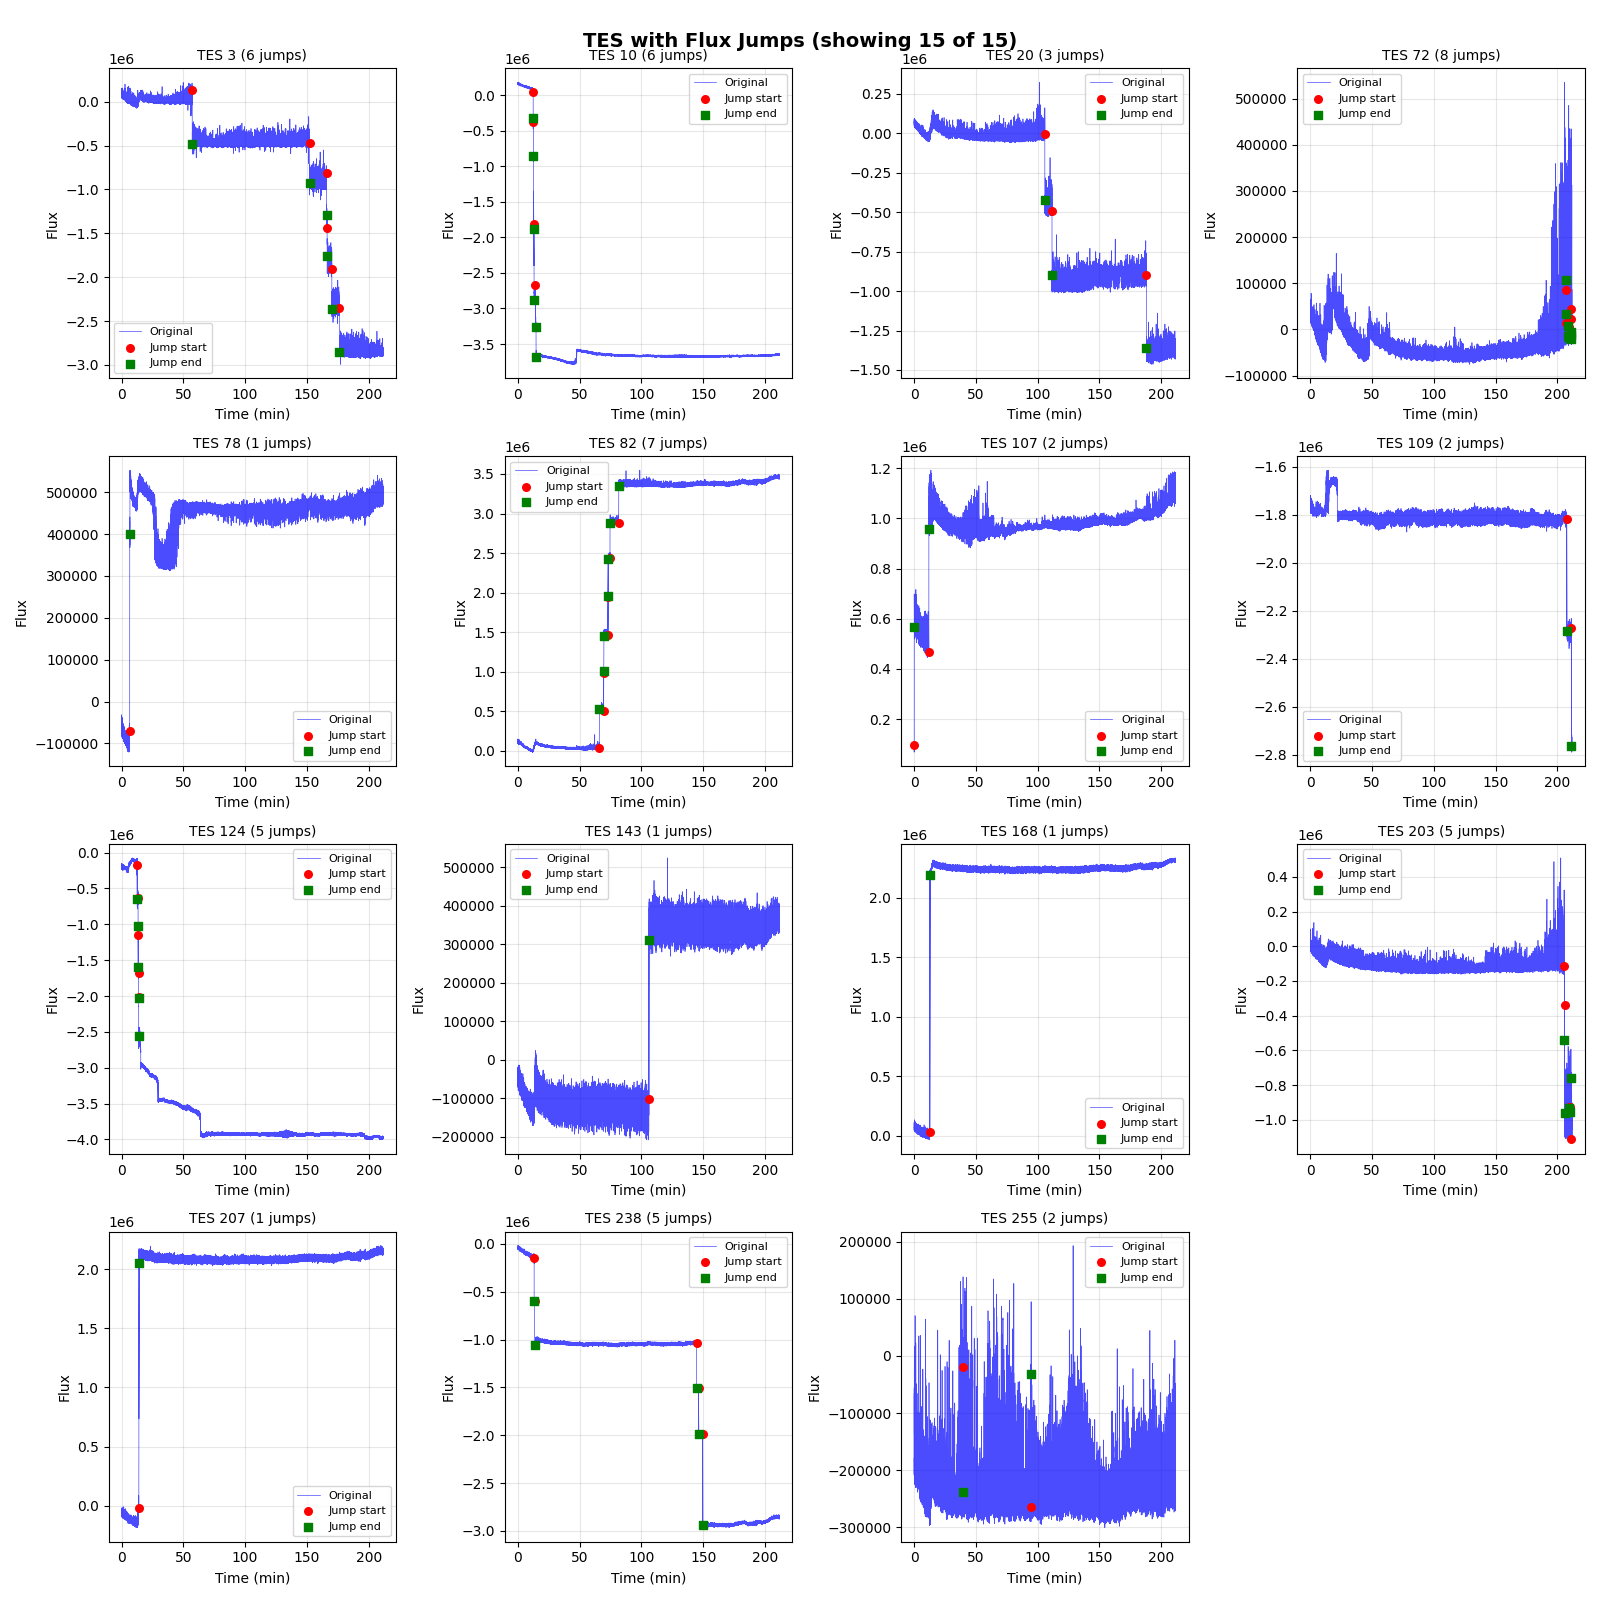

0

In [23]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [34]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=500, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [35]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

In [36]:
%matplotlib inline

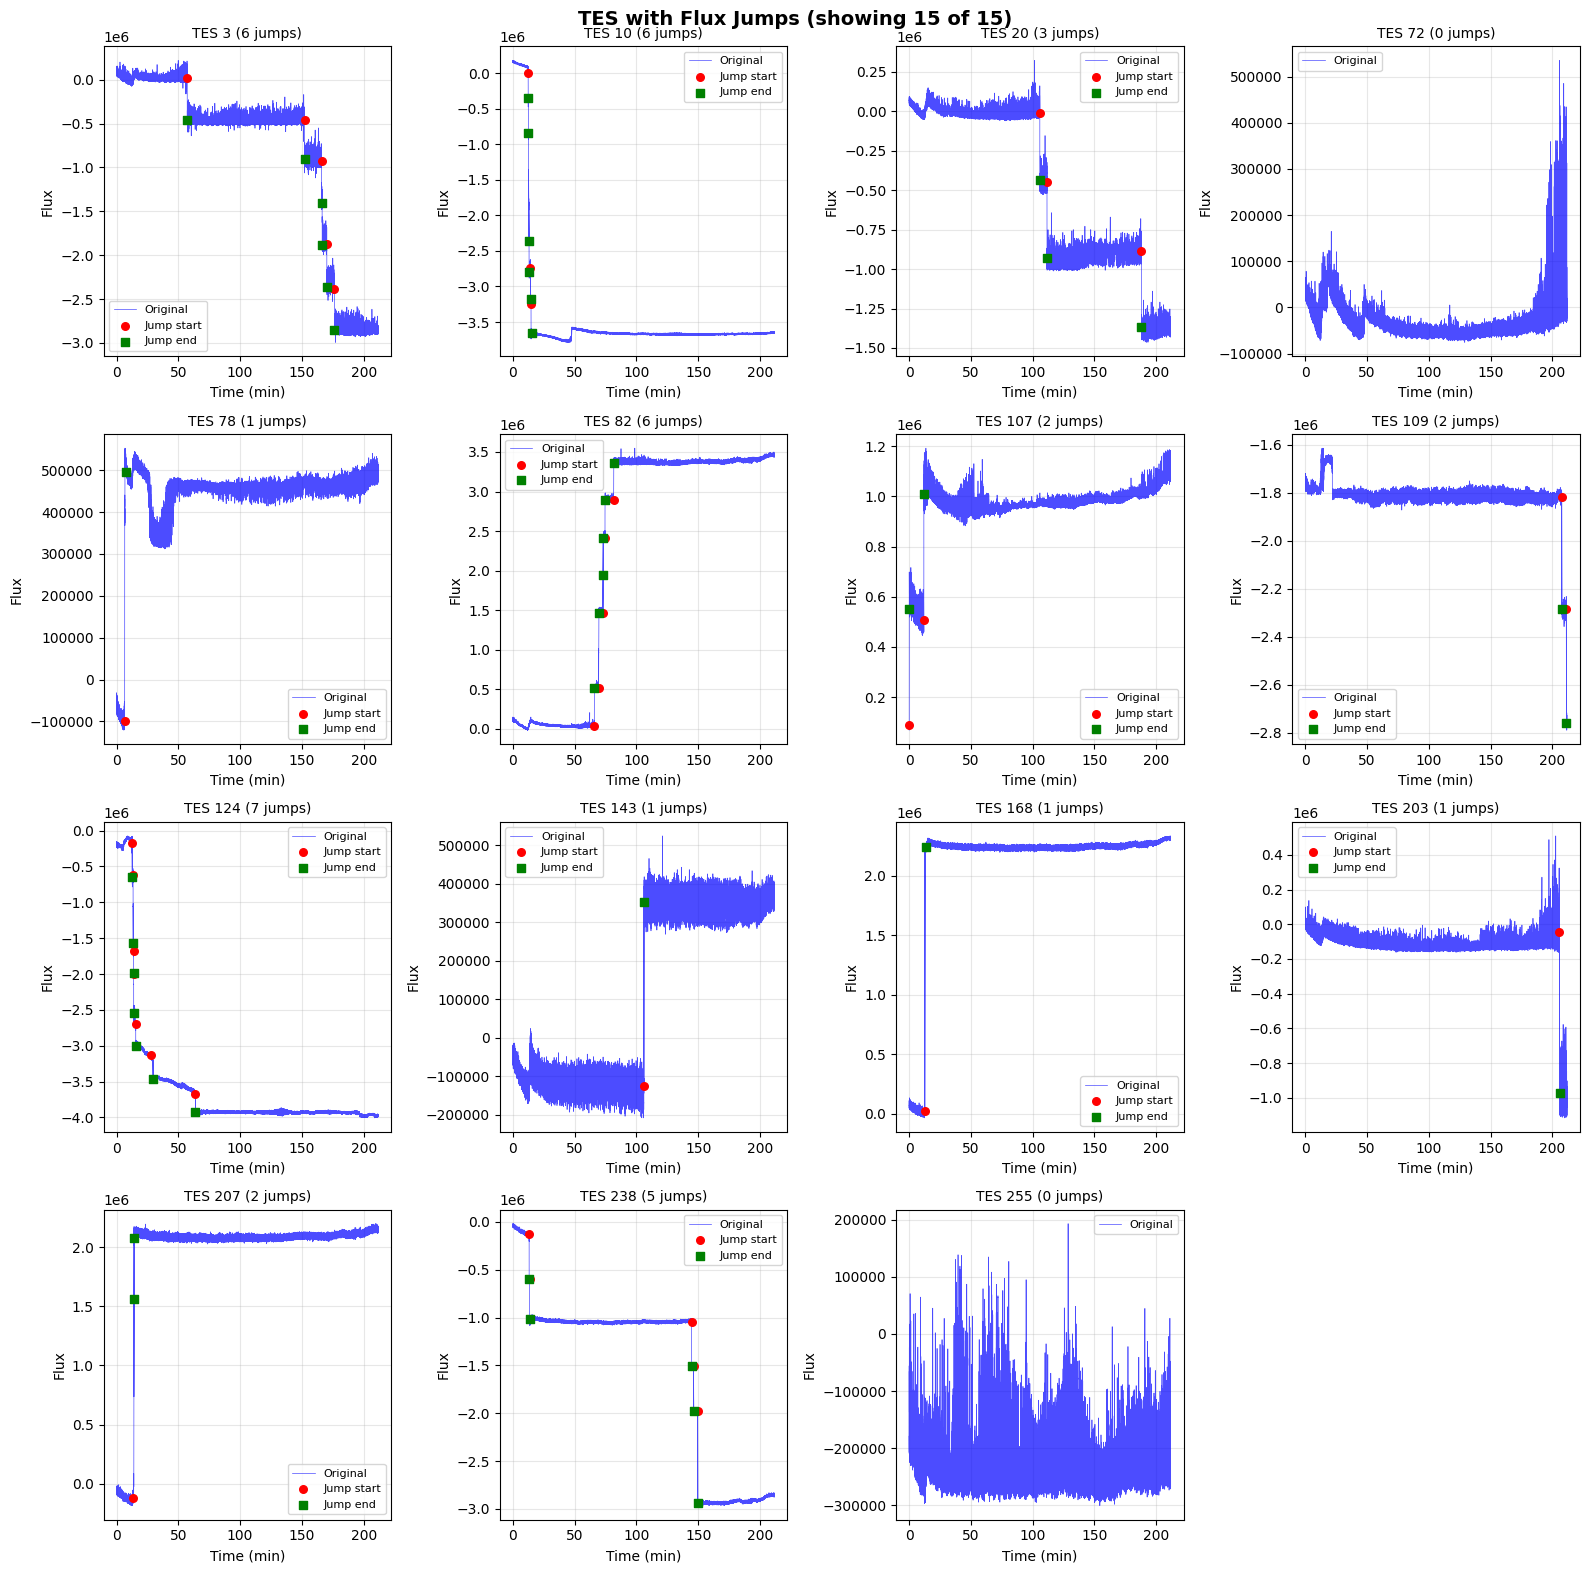

0

In [38]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [39]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [40]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

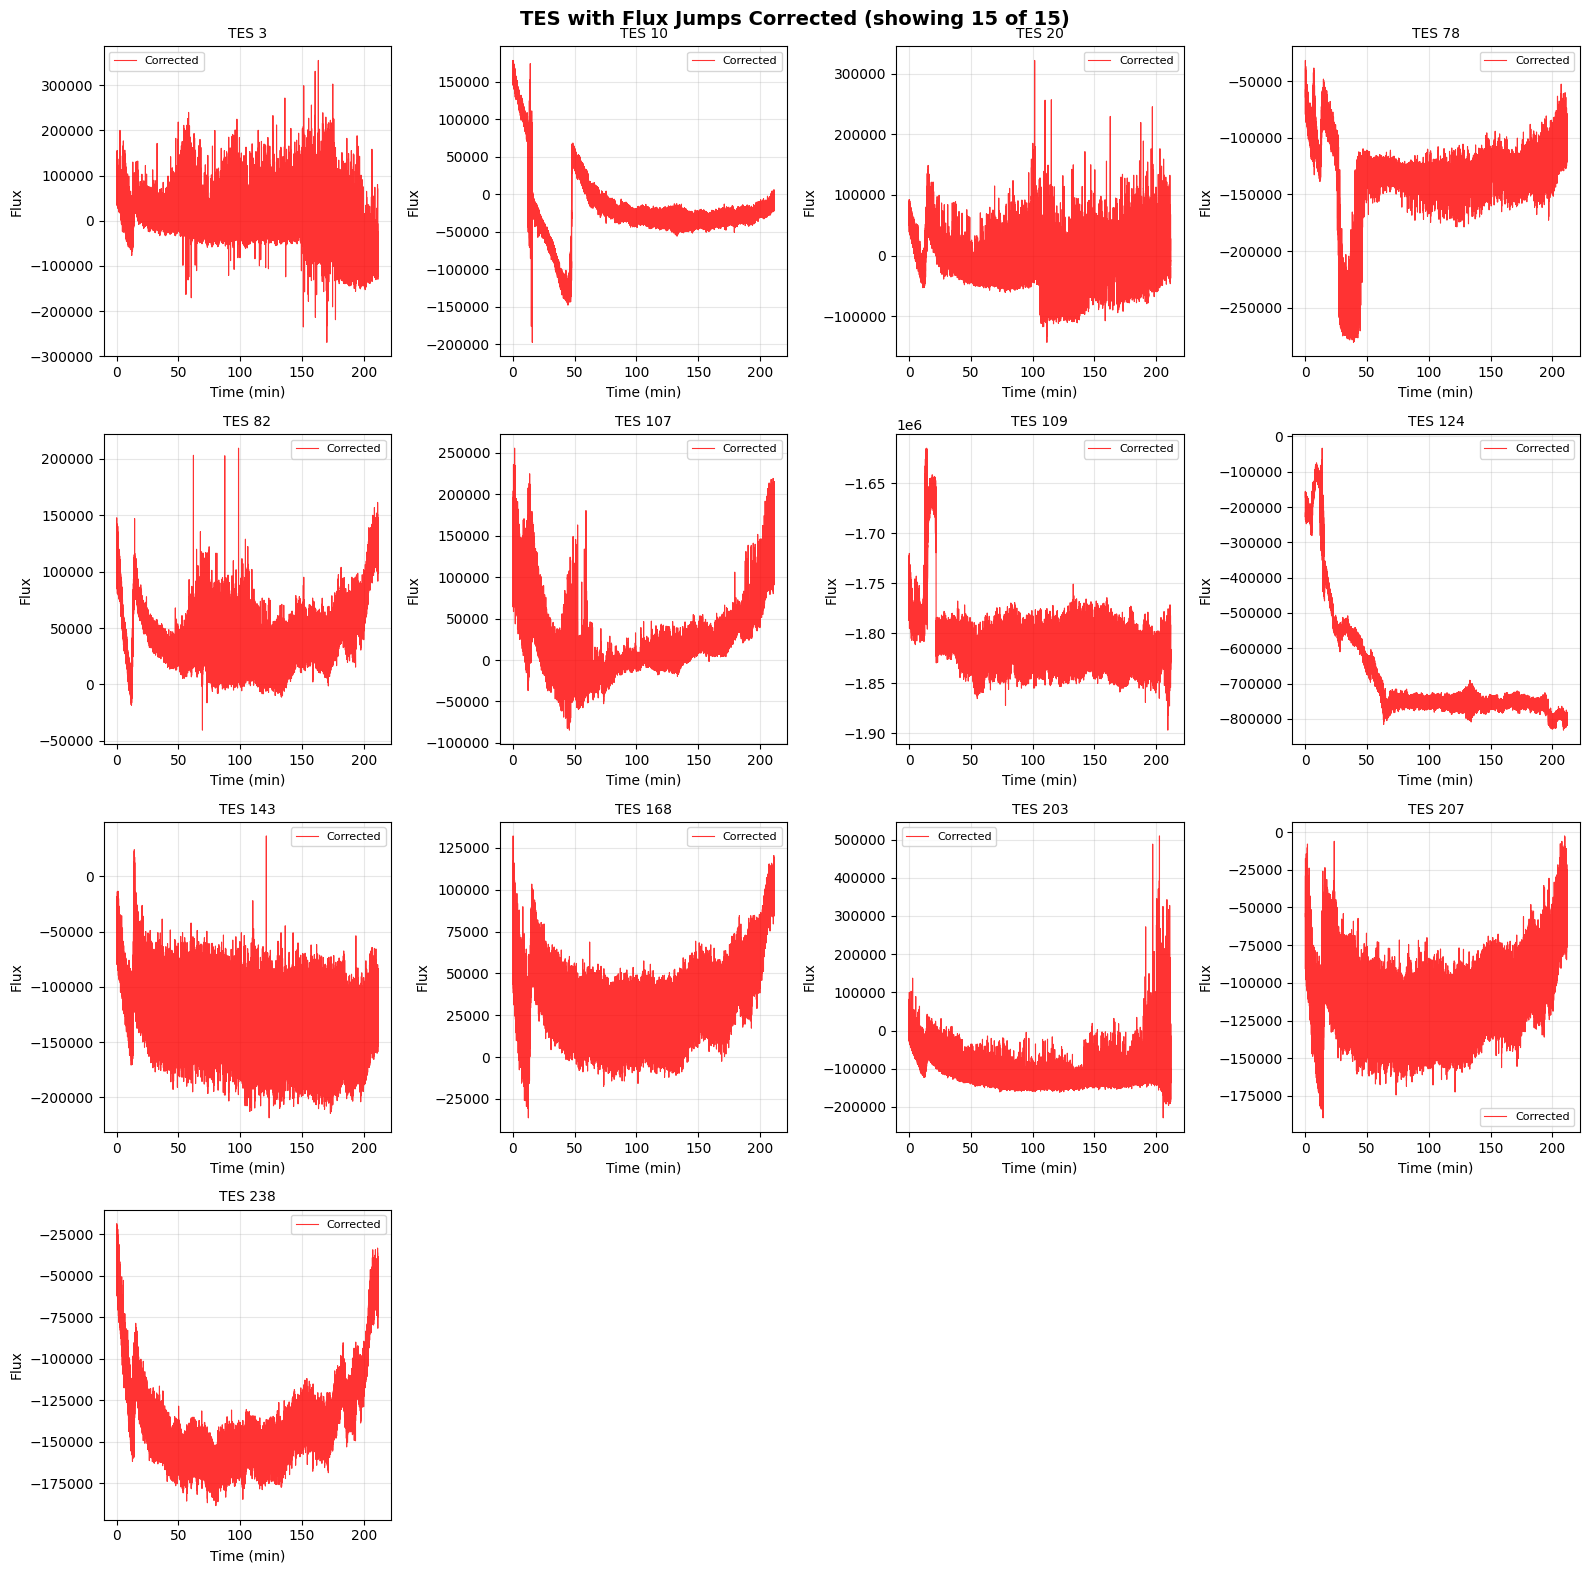

0

In [41]:
utils.plot_corrections(tt, todarray, results)

In [42]:
utils.save_results(results, output_dir=data_path + "year_23_day_2905_11.20.47", dataset_name="23_2905_11.20.47")

Saved pickle file to: ./day_2905_11.20.47/23_2905_11.20.47_results.pkl

All results saved to: ./day_2905_11.20.47
Total files saved: 1



['./day_2905_11.20.47/23_2905_11.20.47_results.pkl']

In [4]:
dirs[2]

'/home/qubic/Calib-TD/2023-05-29/2023-05-29_14.56.02__SkyScan-3V-DomeOpened-Day'

## 14.56.02 skyscan 3V

In [5]:
dataset0 = dirs[2]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-29 14:56:02.380000
ASIC1 Observation end date: 2023-05-29 15:01:29.818000
ASIC2     Observation date: 2023-05-29 14:56:02.382000
ASIC2 Observation end date: 2023-05-29 15:01:29.818000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_14.56.02__SkyScan-3V-DomeOpened-Day/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_14.56.02__SkyScan-3V-DomeOpened-Day/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230529T145602UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230529T145602UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Please enter a

True

In [6]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=51200 which is  2^11*5
number of timesamples along every TES in this dataset: (51200,)


In [7]:
tt[-1]/60

5.457386668523153

In [10]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [11]:
sat = jr.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  18  19  20
  21  22  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  43  45  48  49  51  53  54  55  56  58  59  60  61  62  63  65
  66  67  68  69  70  71  72  74  75  76  77  79  80  81  83  84  85  86
  87  88  89  90  91  92  93  94  95  97  98 100 102 103 105 106 109 111
 112 114 120 121 123 128 129 130 131 132 133 134 135 136 137 138 139 140
 141 142 144 145 146 147 149 150 151 152 155 157 158 159 160 161 162 163
 164 166 167 168 169 170 171 172 173 174 175 177 179 180 181 182 183 184
 185 186 187 188 192 193 194 195 196 197 198 199 200 201 202 204 205 206
 207 208 209 210 211 212 213 214 215 216 217 219 220 222 223 224 231 232
 233 234 235 236 237 238 239 241 242 243 244 247 248 251 254 255]


In [8]:
thr = [2e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 300  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [12]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [14]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [15]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

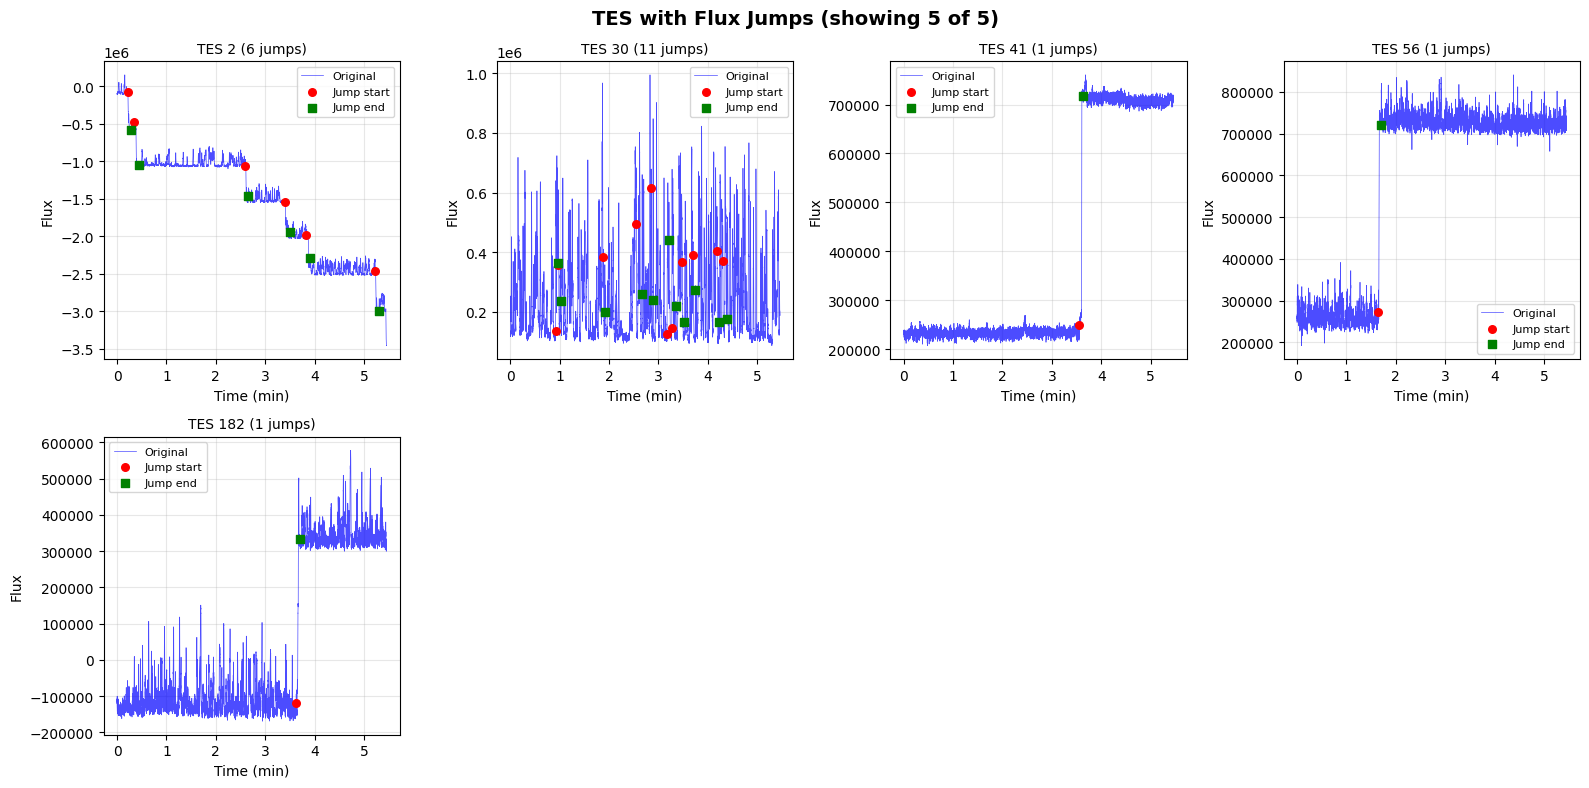

0

In [16]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [33]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=600, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [34]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

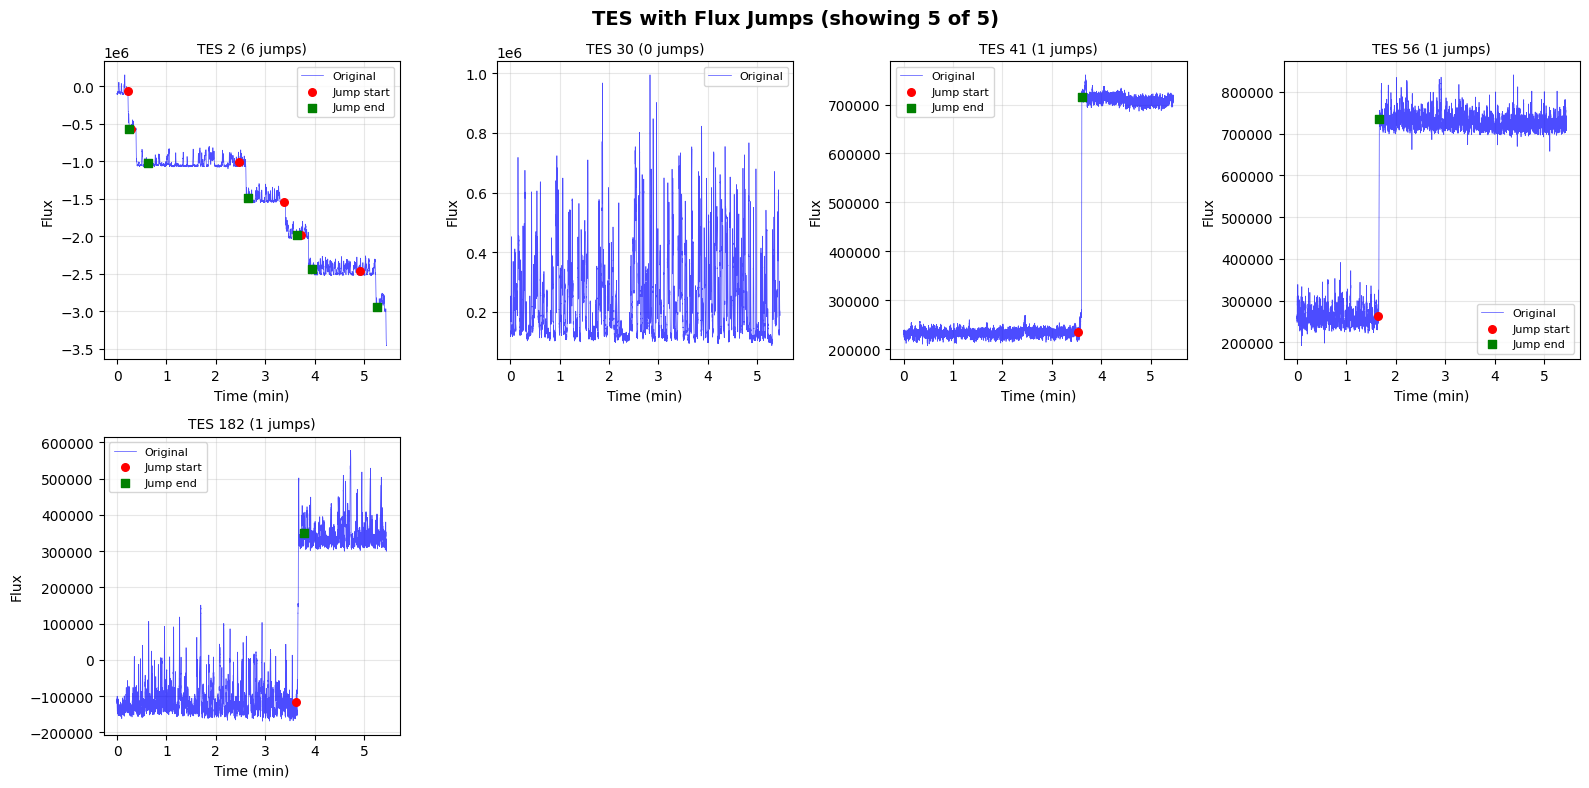

0

In [35]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [36]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [37]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

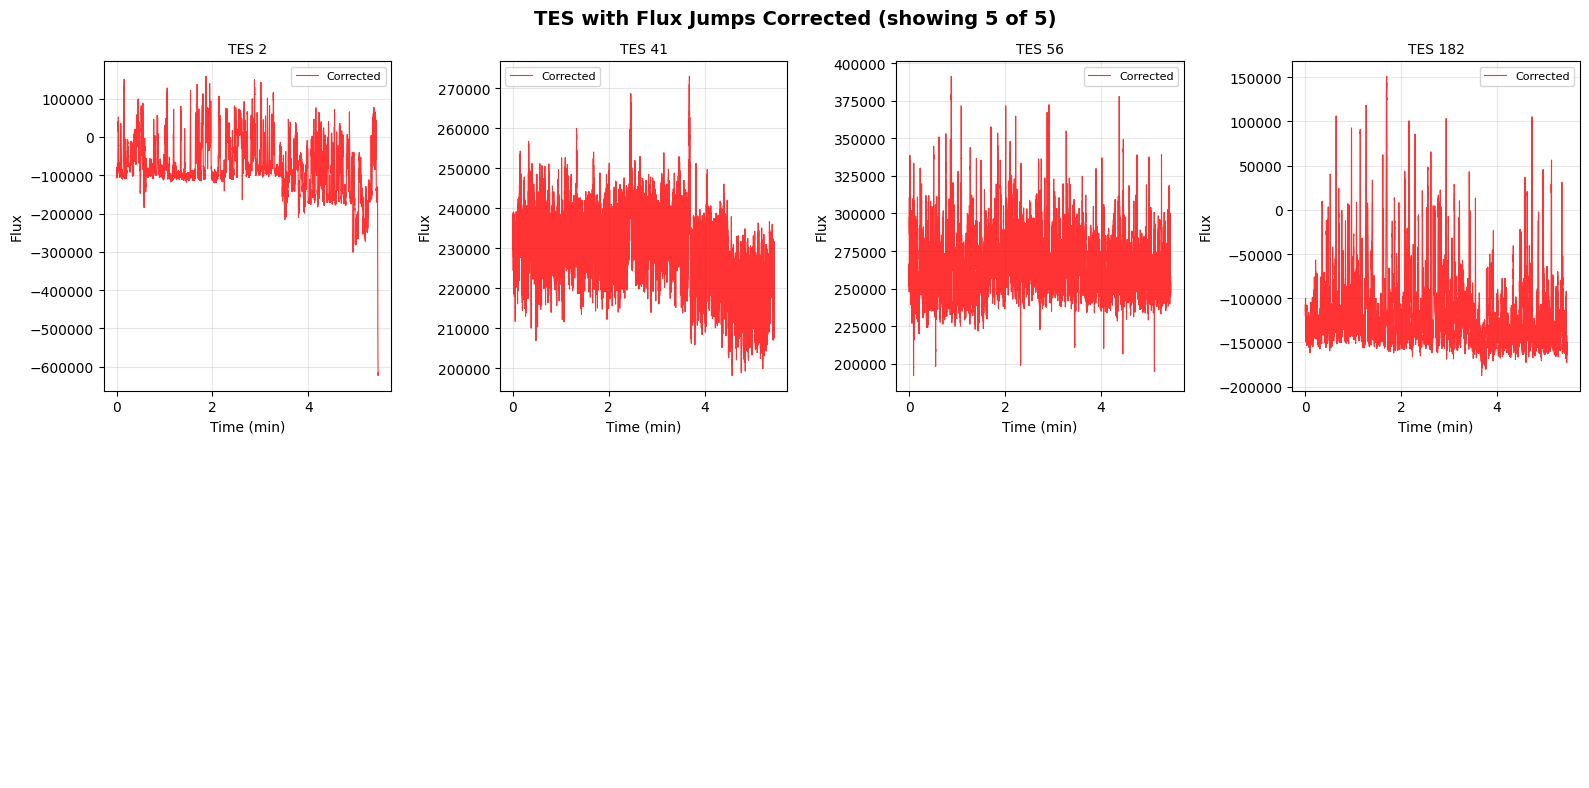

0

In [38]:
utils.plot_corrections(tt, todarray, results)

In [39]:
utils.save_results(results, output_dir=data_path + "year_23_day_2905_14.56.02", dataset_name="23_2905_14.56.02")

Saved pickle file to: ./day_2905_14.56.02/23_2905_14.56.02_results.pkl

All results saved to: ./day_2905_14.56.02
Total files saved: 1



['./day_2905_14.56.02/23_2905_14.56.02_results.pkl']

In [4]:
dirs

array(['/home/qubic/Calib-TD/2023-05-29/2023-05-29_01.45.22__SkyScan-2.5V-DomeOpened-Night',
       '/home/qubic/Calib-TD/2023-05-29/2023-05-29_11.20.47__SkyScan-2.5V-DomeOpened-Day',
       '/home/qubic/Calib-TD/2023-05-29/2023-05-29_14.56.02__SkyScan-3V-DomeOpened-Day',
       '/home/qubic/Calib-TD/2023-05-29/2023-05-29_15.19.18__SkyScan-2V-DomeOpened-Day',
       '/home/qubic/Calib-TD/2023-05-29/2023-05-29_15.21.00__SkyScan-2V-DomeOpened-Day',
       '/home/qubic/Calib-TD/2023-05-29/2023-05-29_19.37.22__SkyDip-2V-DomeOpened-Day'],
      dtype='<U82')

## 19.37.22 skydip 

In [5]:
dataset0 = dirs[5]
a = qubicfp()
a.read_qubicstudio_dataset(dataset0)

ASIC1     Observation date: 2023-05-29 19:37:22.748000
ASIC1 Observation end date: 2023-05-29 19:39:33.915000
ASIC2     Observation date: 2023-05-29 19:37:22.776000
ASIC2 Observation end date: 2023-05-29 19:39:33.915000
No MMR data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_19.37.22__SkyDip-2V-DomeOpened-Day/Hks
No MGC data found in directory: /home/qubic/Calib-TD/2023-05-29/2023-05-29_19.37.22__SkyDip-2V-DomeOpened-Day/Hks
No hornswitch data found in directory: /home/qubic/Calib-TD/hornswitch
Please give a valid asic number
WARNING! The bias phase is different between the ASICs.  To see where, please set verbosity>2 and rerun bias_phase()
No previously saved filter information: QUBIC_TES_ASIC1_20230529T193722UTC.filter.pickle
No previously saved filter information: QUBIC_TES_ASIC2_20230529T193722UTC.filter.pickle
Not a valid housekeeping ID: MMR_HK
Not a valid housekeeping ID: MGC_HK
Not a valid housekeeping ID: TES STAGE
Please give an asic number
Please enter a v

True

In [6]:
tod = a.tod()
timeaxis = tod[0]
todarray = tod[1]
init = timeaxis[0]
tt = timeaxis - init

print('number of timesamples along every TES in this dataset:', np.shape(todarray[0,:]))

suggest nsamples=20608 which is  2^7*7*23
number of timesamples along every TES in this dataset: (20608,)


In [7]:
# TES_yes: idx TES with flux jumps found by haar filter
# TES_no: idx TES with no flux jumps found
# TES_yes_dt: refinament of idx TES with flux jumps using DT (could be equal to TES_yes)
# jump_data: "idx", xc", "xcf", "nc"
# dt_jump_data: "idx", "xcdt", "xcfdt", "ncdt"
# corrected data: idx and TES corrected
# offset: amplitudes of jumps

results = {
    'TES_yes': [],
    'TES_no': [],
    'TES_yes_dt': [],
    'jump_data': {},
    'dt_jump_data': {},
    'corrected_data': {},
    'offset': {}
    }

In [8]:
sat = jr.saturation(sat_value=4.19e6, TES_number=256) 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

#IV class. You have to load the directory and the filename of the IV analysis
#IVdict2025.yaml or IVdict2023.yaml are the dicts with the IV information from 2025 and 2022-2023
iv = jr.badIV(directory=soft_path, n_times=10, TES_number=256, filename="IVdict2023.yaml") 
iv_mask = iv.select_badIV()

good_mask = sat_mask & iv_mask        # Create a mask with both saturation and bad IV
good_idx  = np.where(good_mask)[0]    # index of TES with good IV and no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  1   2   3   4   5   6   7   8  10  13  14  15  18  19  21  22  24  25
  26  27  28  30  31  32  33  34  35  36  37  38  39  40  41  43  48  49
  50  51  52  53  57  58  59  60  61  62  63  65  66  67  68  69  70  71
  72  74  75  76  77  79  80  81  82  84  85  86  87  88  89  90  91  92
  93  94  95  97  98 100 102 103 105 108 109 111 112 114 115 116 120 121
 123 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 144 145
 146 147 151 152 155 157 158 159 160 161 162 163 166 167 168 169 170 171
 172 173 174 175 177 178 179 180 181 182 183 184 185 186 187 188 192 193
 194 195 196 197 198 199 200 201 202 204 205 206 207 208 209 210 211 212
 213 214 216 217 219 220 222 223 224 231 232 233 234 235 236 238 239 241
 243 244 248 251 254 255]


In [19]:
thr = [2e5]#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 300  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [20]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf, thr_used = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf, 'thr_used': thr_used}

In [21]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [22]:
results['TES_yes'] = TES_yes
results['TES_no'] = TES_no
results['jump_data'] = jump_data

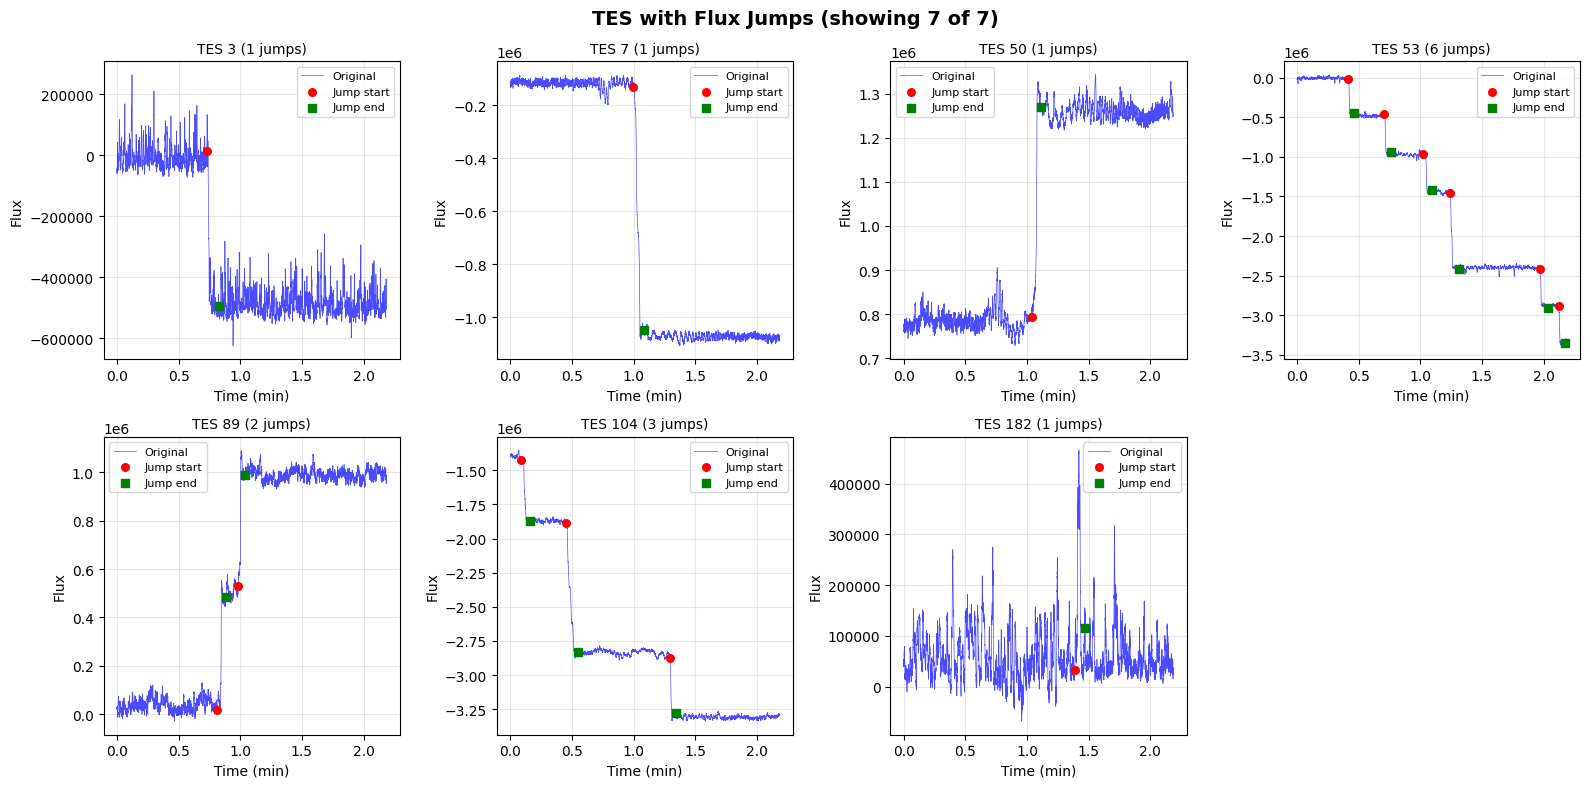

0

In [23]:
utils.plot_jump_detections(tt, todarray, results, DT=False)

In [27]:
# Step 2: Decision Tree Refinement
dt = jr.DT(thr_count=300, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [28]:
results['dt_jump_data'] = dt_jump_data
results['TES_yes_dt'] = TES_with_dt_jumps

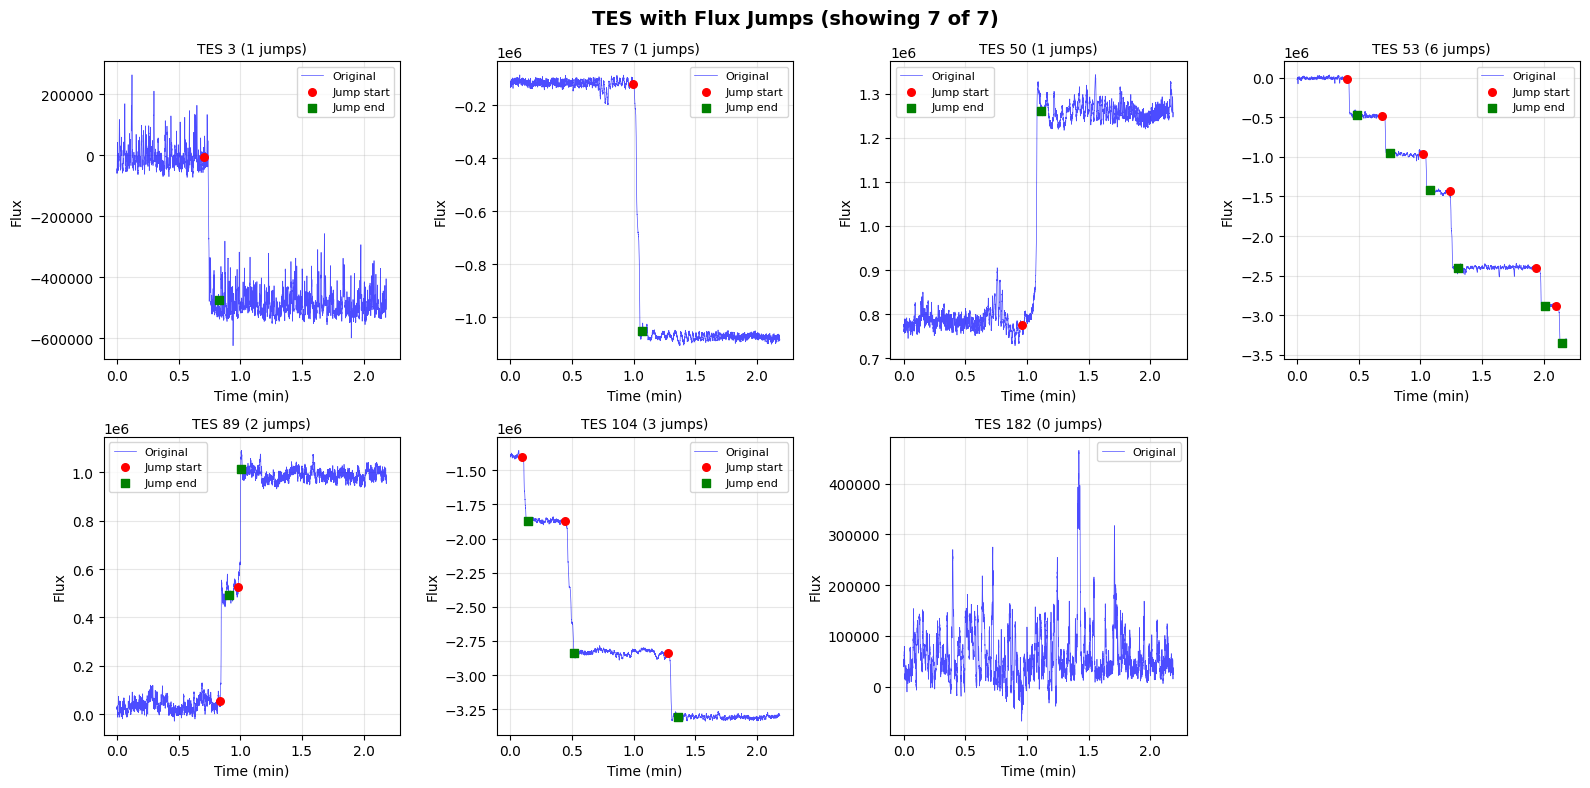

0

In [29]:
utils.plot_jump_detections(tt, todarray, results, DT=True)

In [30]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [31]:
results['corrected_data'] = corrected_tod
results['offset'] = offset

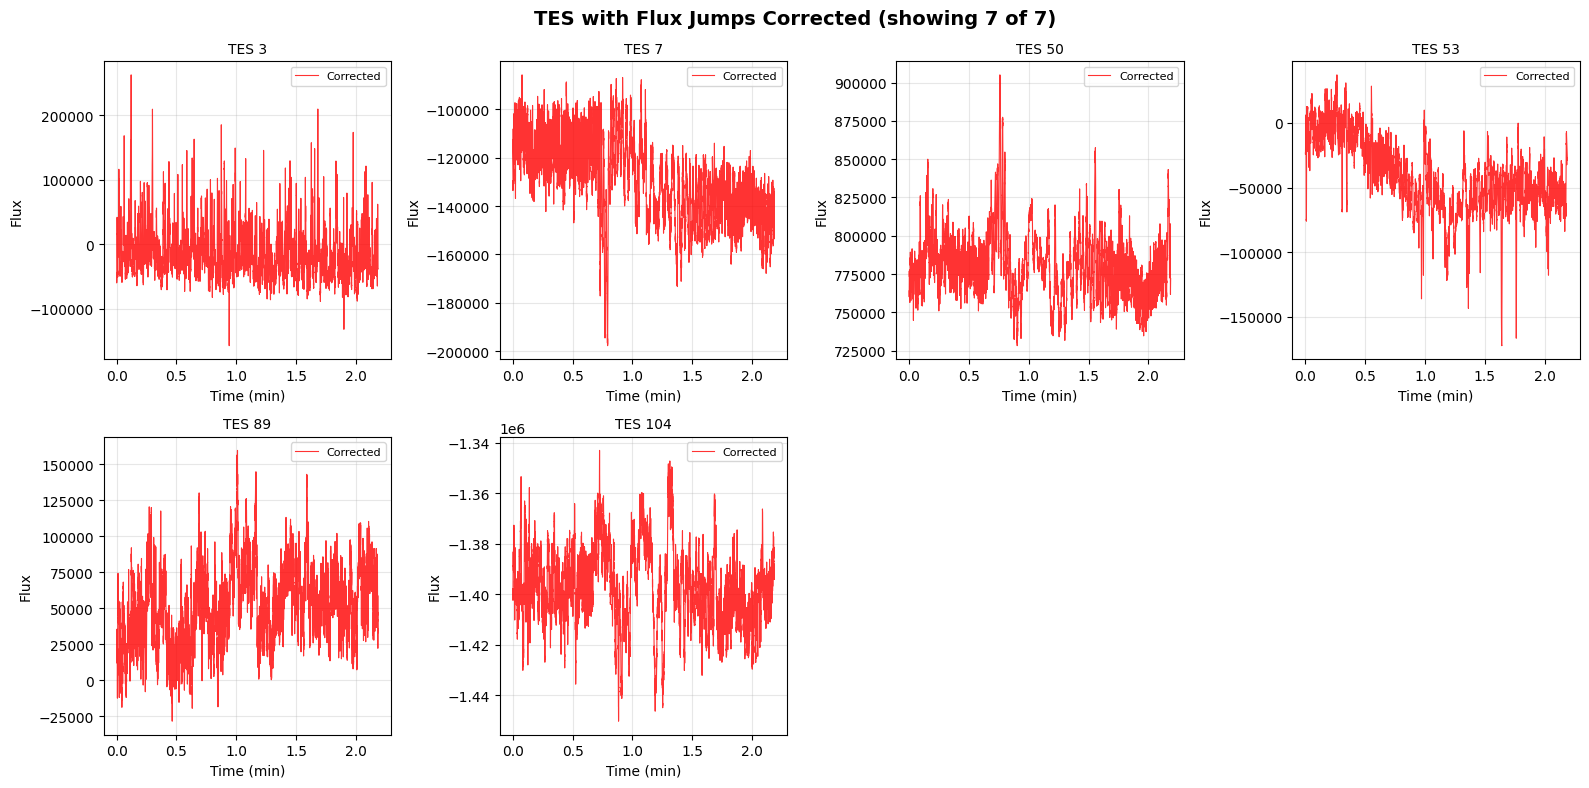

0

In [32]:
utils.plot_corrections(tt, todarray, results)

In [33]:
utils.save_results(results, output_dir=data_path + "year_23_day_2905_19.37.22", dataset_name="23_2905_19.37.22")

Saved pickle file to: ./day_2905_19.37.22/23_2905_19.37.22_results.pkl

All results saved to: ./day_2905_19.37.22
Total files saved: 1



['./day_2905_19.37.22/23_2905_19.37.22_results.pkl']